In [1]:
import sys 
sys.path.append("/Users/shubham/Documents/Github/acceleration-flow-matching/src")


In [8]:
import torch
import torch.nn as nn
from torch.optim import Adam
from models import BaseViT, PatchEmbedding
from data_loader import train_loader
from tqdm import tqdm
from diffusion import DDPMSampler
from utils import visualize_samples

In [5]:
def train_ddpm(model_sampler: DDPMSampler, train_loader, device='cpu', epochs=5, lr=1e-4):
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    num_steps = 1000
    betas = torch.linspace(0.0001, 0.02, num_steps, device=device)
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    sqrt_alpha_bars = torch.sqrt(alpha_bars)
    sqrt_1_minus_alpha_bars = torch.sqrt(1 - alpha_bars)
    
    model_sampler.model.train()

    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"DDPM Epoch {epoch+1}/{epochs}")
        
        for batch_idx, (x, _) in enumerate(progress_bar):
            
            loss = model_sampler.forward_loss(x, num_steps, criterion)

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model_sampler.model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - DDPM Loss: {avg_loss:.6f}\n")
        
    return model_sampler.model

In [6]:
device = 'cpu'
model = BaseViT(img_size=32, patch_size=4, embed_dim=192, depth=12, num_heads=3)
model = model.to(device)

model_ddpm = DDPMSampler(model)


model = train_ddpm(model_ddpm, train_loader, device=device, epochs=1, lr=1e-4)



DDPM Epoch 1/1:   0%|          | 0/782 [00:00<?, ?it/s]

DDPM Epoch 1/1: 100%|██████████| 782/782 [11:54<00:00,  1.09it/s, loss=0.0774]

Epoch 1 - DDPM Loss: 0.252231



In [7]:
torch.save(model.state_dict(), 'ddpm_model.pth')
print("✓ Model saved to ddpm_model.pth")

✓ Model saved to ddpm_model.pth


DDPM: 100%|██████████| 1000/1000 [00:30<00:00, 32.46it/s]


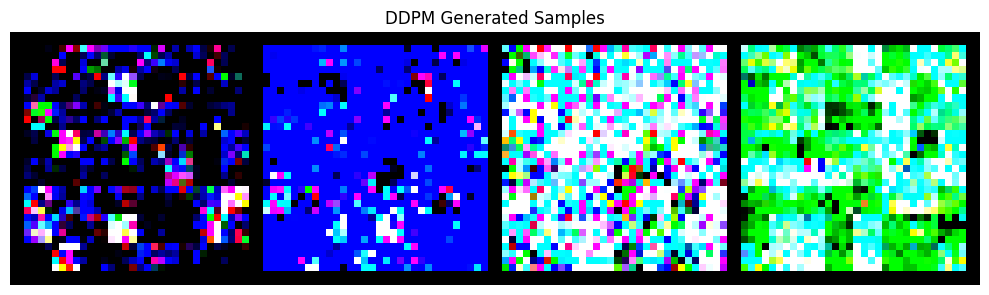

In [11]:
sampler = model_ddpm


# Cell 4: Test and Benchmark

# Generate samples
x_noise = torch.randn(4, 3, 32, 32, device=device)
x_samples = sampler.sample(x_noise, t_steps=1000, verbose=True)


# Benchmark
# result = benchmark(sampler, batch_size=4, t_steps=50, num_runs=2)
# print(f"\nDDPM 50 steps: {result['mean_time_s']:.2f}s ± {result['std_time_s']:.2f}s")

# # Visualize
visualize_samples(x_samples, title="DDPM Generated Samples")